# Exercise 4 - Chemostat: Yeast Biomass Production

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


**Question a)**
In a chemostat at steady state, the specific growth rate $\mu$ equals the dilution rate $D$:

$$D = \mu = \mu_{\max} \frac{S}{K_s + S}$$

where:
- $\mu_{\max}$ is the maximum specific growth rate (h⁻¹)
- $K_s$ is the saturation (Monod) constant (g/L)
- $S$ is the steady-state substrate concentration (g/L)

This balance arises because at steady state, cell growth exactly compensates for dilution losses.

Taking the reciprocal of the Monod equation:

$$\frac{1}{D} = \frac{K_s}{\mu_{\max}} \cdot \frac{1}{S} + \frac{1}{\mu_{\max}}$$

Plotting $1/D$ versus $1/S$ yields a straight line with:
- slope $= K_s / \mu_{\max}$
- y-intercept $= 1 / \mu_{\max}$
- x-intercept $= -1 / K_s$

The two highest dilution rates ($D = 0.80$ and $D = 0.84$ h⁻¹) are excluded from the fit. At these operating points, cell concentration drops sharply and residual substrate rises steeply, indicating washout. This means that the culture can no longer sustain steady-state growth. Including these points would violate the steady-state assumption.

  Monod parameter estimation (part a)
  Slope     (Ks / µmax) = 0.2415  h·g/L
  Intercept (1 / µmax)  = 0.2690  h
  µmax                  = 3.7175  h⁻¹
  Ks                    = 0.8979  g/L


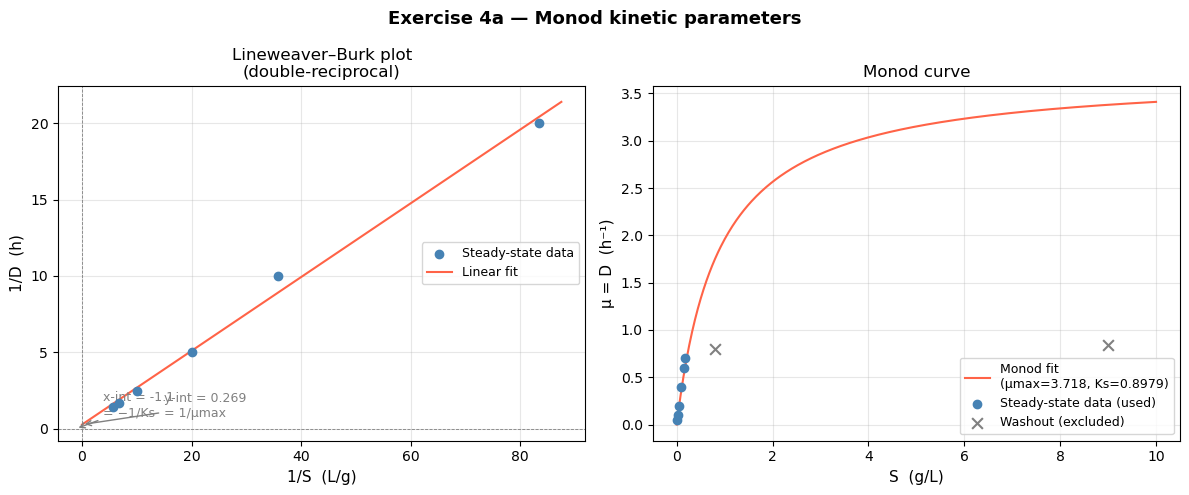

In [2]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])  
X = np.array([3.2,  3.7,  4.0,  4.4,  4.75, 4.9,  4.5,  0.5])   
S = np.array([0.012,0.028,0.050,0.100,0.150,0.176,0.800,9.000])  
S0 = 10.0  

mask   = D <= 0.70
D_fit  = D[mask]
S_fit  = S[mask]

inv_D = 1.0 / D_fit
inv_S = 1.0 / S_fit

slope, intercept = np.polyfit(inv_S, inv_D, 1)

mu_max = 1.0 / intercept       
Ks     = slope * mu_max          

print("=" * 45)
print("  Monod parameter estimation (part a)")
print("=" * 45)
print(f"  Slope     (Ks / µmax) = {slope:.4f}  h·g/L")
print(f"  Intercept (1 / µmax)  = {intercept:.4f}  h")
print(f"  µmax                  = {mu_max:.4f}  h⁻¹")
print(f"  Ks                    = {Ks:.4f}  g/L")
print("=" * 45)

inv_S_line = np.linspace(0, max(inv_S) * 1.05, 300)
inv_D_line = slope * inv_S_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(inv_S, inv_D, color="steelblue", zorder=5, label="Steady-state data")
ax1.plot(inv_S_line, inv_D_line, color="tomato", label="Linear fit")

ax1.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax1.axvline(0, color="grey", linewidth=0.6, linestyle="--")

ax1.annotate(f"y-int = {intercept:.3f}\n= 1/µmax",
             xy=(0, intercept), xytext=(15, intercept + 0.5),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")
x_int = -intercept / slope          # x-intercept = −1/Ks
ax1.annotate(f"x-int = {x_int:.1f}\n= −1/Ks",
             xy=(x_int, 0), xytext=(x_int + 5, 0.8),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")

ax1.set_xlabel("1/S  (L/g)", fontsize=11)
ax1.set_ylabel("1/D  (h)", fontsize=11)
ax1.set_title("Lineweaver–Burk plot\n(double-reciprocal)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
S_range = np.linspace(0, S0, 500)
mu_monod = mu_max * S_range / (Ks + S_range)

ax2.plot(S_range, mu_monod, color="tomato", label=f"Monod fit\n(µmax={mu_max:.3f}, Ks={Ks:.4f})")
ax2.scatter(S_fit, D_fit, color="steelblue", zorder=5, label="Steady-state data (used)")
ax2.scatter(S[~mask], D[~mask], color="grey", marker="x", zorder=5, s=60, label="Washout (excluded)")

ax2.set_xlabel("S  (g/L)", fontsize=11)
ax2.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax2.set_title("Monod curve", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Exercise 4a — Monod kinetic parameters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ex4a_monod.png", dpi=150, bbox_inches="tight")
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $\mu_{\max}$ | 3.7175 | h⁻¹ |
| $K_s$ | 0.8979 | g/L |


The value of $K_s$ falls in the low mg/L range, which is characteristic of glucose-limited yeast growth.  The organism has a high affinity for the carbon source and can grow efficiently even at very low substrate concentrations.

The double-reciprocal transformation amplifies error at low $S$ values (high $1/S$), analogous to the Lineweaver–Burk plot in enzyme kinetics. The fitted parameters should therefore be interpreted with this limitation in mind; a non-linear least-squares fit directly to the Monod equation would give a more statistically robust estimate.
